In [1]:
import numpy as np
import xarray as xr
import matplotlib as plt
import xrft as xt

In [76]:
internal_var_da = xr.open_dataset('residual_H+_ssp245_r1.nc').squeeze()

In [77]:
internal_var_da

<xarray.Dataset> Size: 62MB
Dimensions:               (time: 1392, lat: 61, lon: 91)
Coordinates:
  * time                  (time) object 11kB 1985-01-15 12:00:00 ... 2100-12-...
  * lat                   (lat) float32 244B -29.88 -29.38 ... 28.62 29.62
  * lon                   (lon) float32 364B 30.12 31.12 32.12 ... 119.1 119.9
Data variables:
    internal_variability  (time, lat, lon) float64 62MB ...

In [78]:
lat_range = slice(-30, 30)
lon_range = slice(30, 120)

internal_var_avg = internal_var_da.sel(lat=lat_range, lon=lon_range, time=slice('2015', '2100'))

# 2. Spatial mean
internal_var_sp_avg = internal_var_avg.mean(['lat', 'lon'])

# 3. Group by year and calculate max and min over the 12 months of each year
yearly_max = internal_var_sp_avg.groupby('time.year').max()
yearly_min = internal_var_sp_avg.groupby('time.year').min()

# 4. Compute amplitude (max - min) for each year
amp = yearly_max - yearly_min

Trend per decade: 0.00030 units/decade
P-value: 0.66295
R-squared: 0.00227


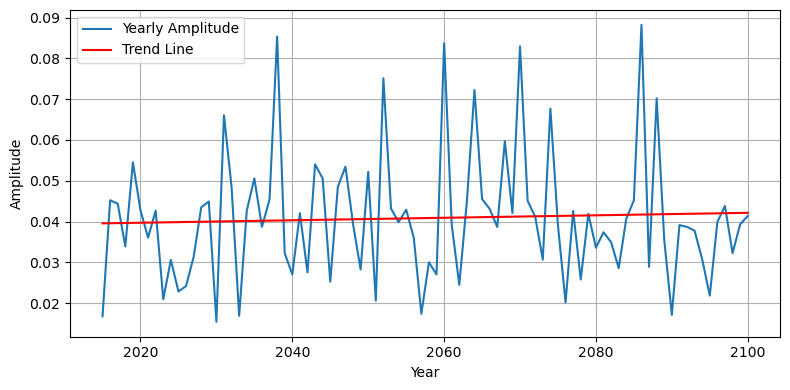

In [79]:
from scipy.stats import linregress
import matplotlib.pyplot as plt


years = amp.year.values
amplitude = amp.internal_variability.values
amplitude= amplitude*(10**9)
slope, intercept, r_value, p_value, std_err = linregress(years, amplitude)

trend_per_decade = slope * 10

print(f"Trend per decade: {trend_per_decade:.5f} units/decade")
print(f"P-value: {p_value:.5f}")
print(f"R-squared: {r_value**2:.5f}")

plt.figure(figsize=(8, 4))
plt.plot(years, amplitude, label='Yearly Amplitude')
plt.plot(years, intercept + slope * years, 'r', label='Trend Line')
plt.xlabel('Year')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [75]:
# amp.to_netcdf('amp_H+_ssp585_r1.nc')